# Create perturbed $^{235}$U thermal FY files using JEFF-4.0 covariance evaluation

In [6]:
import sandy
import matplotlib.pyplot as plt
import seaborn as sns
from os.path import join, dirname
import pandas as pd
import numpy as np
import random, sys

## Extract FYs and covariance data for U235 thermal fission

In [2]:
nuclide, e = 922350, 0.0253
corr = sandy.fy.get_jeff40_fy_correlation_matrix(nuclide, 0.0253)
tape = sandy.get_endf6_file("jeff_40", "nfpy", nuclide)
nfpy = sandy.Fy.from_endf6(tape)

In [3]:
idx = nfpy.data.query(f"E==0.0253 & MT==454").index
ifyth = nfpy.data.loc[idx]

In [4]:
abs_cov = sandy.cov.corr2cov(corr, ifyth.DFY.values)                                          # absolute covariance matrix
rel_cov = sandy.CategoryCov(
    np.divide(abs_cov, ifyth.FY.values.reshape(-1, 1) @ ifyth.FY.values.reshape(1, -1)), # convert to relative terms
    index=pd.MultiIndex.from_frame(ifyth[["ZAM", "E", "ZAP"]]),
    columns=pd.MultiIndex.from_frame(ifyth[["ZAM", "E", "ZAP"]]),
)

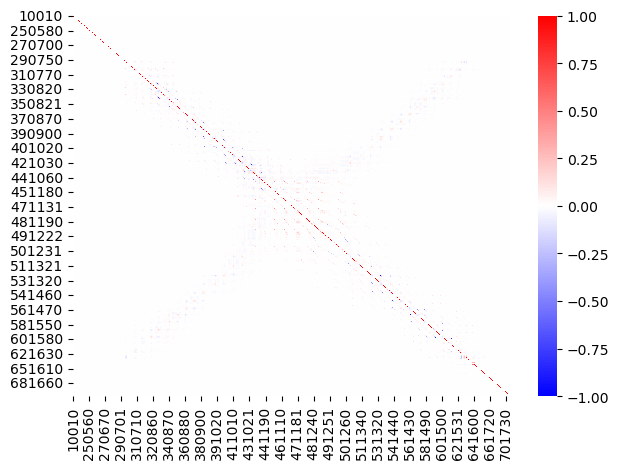

In [7]:
fig, ax = plt.subplots()
sns.heatmap(corr, vmin=-1, vmax=1, cmap="bwr", ax=ax)
fig.tight_layout()

## Generate perturbation coefficients and write them to file

In [8]:
seed = random.randrange(2**32 - 1)    # create a seed
seed = 1444271359                     # or use always the same
nsmp = 100                            # sample size
smp = rel_cov.sampling(nsmp, seed=seed)

In [9]:
with pd.ExcelWriter(f'PERT_{nuclide}TH_MF8_MT454.xlsx') as writer:
    smp.data.to_excel(writer, index=True, sheet_name="SMP")

## Read coefficients from perturbation file and generate random FY ENDF-6 files

Skip the part above if you already have the file of perturbations.

In [10]:
smps = sandy.samples.read_fy_samples(f'PERT_{nuclide}TH_MF8_MT454.xlsx')
smp = smps["IFY"]

In [11]:
idx_ify = nfpy.data.query(f"E==@e & MT==454").index
idx_cfy = nfpy.data.query(f"E==@e & MT==459").index

In [12]:
smp_min = 0   # write ENDF-6 file only in the sample range [smp_min, smp_max]
smp_max = 99
file_template = "{}_fycov_{}.jeff40"
for ismp in range(smp_min, smp_max+1):
    file = file_template.format(nuclide, ismp)
    f = sandy.Fy(nfpy.data.copy())
    f.data.loc[idx_ify, "DFY"] = f.data.loc[idx_ify, "FY"]            # just for me, i copy the original IFYs where uncertainties should be, so i can compare them to the perturbed ones (anyways I don't use uncertainties)
    f.data.loc[idx_cfy, "DFY"] = f.data.loc[idx_cfy, "FY"]            # same but for CFYs
    f.data.loc[idx_ify, "FY"] *= smp.data[ismp].values                # IMPORTANT, this does not update the CFYs, which in random ENDF-6 file are inconsistent with the perturbed IFYs
    # f = f.apply_qmatrix(942390, 0.0253, rdd, keep_fy_index=True)      # Run this if you want to update the CFYs (slower), or else comment it out
    print(f"writing file '{file}'...")
    f.to_endf6(tape).to_file(file)

writing file '922350_fycov_0.jeff40'...
writing file '922350_fycov_1.jeff40'...
writing file '922350_fycov_2.jeff40'...
writing file '922350_fycov_3.jeff40'...
writing file '922350_fycov_4.jeff40'...
writing file '922350_fycov_5.jeff40'...
writing file '922350_fycov_6.jeff40'...
writing file '922350_fycov_7.jeff40'...
writing file '922350_fycov_8.jeff40'...
writing file '922350_fycov_9.jeff40'...
writing file '922350_fycov_10.jeff40'...
writing file '922350_fycov_11.jeff40'...
writing file '922350_fycov_12.jeff40'...
writing file '922350_fycov_13.jeff40'...
writing file '922350_fycov_14.jeff40'...
writing file '922350_fycov_15.jeff40'...
writing file '922350_fycov_16.jeff40'...
writing file '922350_fycov_17.jeff40'...
writing file '922350_fycov_18.jeff40'...
writing file '922350_fycov_19.jeff40'...
writing file '922350_fycov_20.jeff40'...
writing file '922350_fycov_21.jeff40'...
writing file '922350_fycov_22.jeff40'...
writing file '922350_fycov_23.jeff40'...
writing file '922350_fycov

## Compare sample estimates of mass yields with deterministic uncertainty propagation (sandwich formula) 

In [14]:
mfy = {}
for ismp in range(smp_min, smp_max+1):
    mfy[ismp] = sandy.Fy.from_endf6(sandy.Endf6.from_file(file_template.format(nuclide, ismp))).get_mass_yield(zam=nuclide, e=e)
mfy = pd.DataFrame(mfy).rename_axis("SMP", axis=1)

S = sandy.Fy(nfpy.data.query(f"MT==454 and E==@e")).get_mass_yield_sensitivity()
C = pd.DataFrame(abs_cov, index=ifyth.ZAP.values, columns=ifyth.ZAP.values)
cov_mfy = sandy.CategoryCov(S @ C @ S.T)

mu = nfpy.get_mass_yield(zam=nuclide, e=e)
sigma = cov_mfy.get_std()

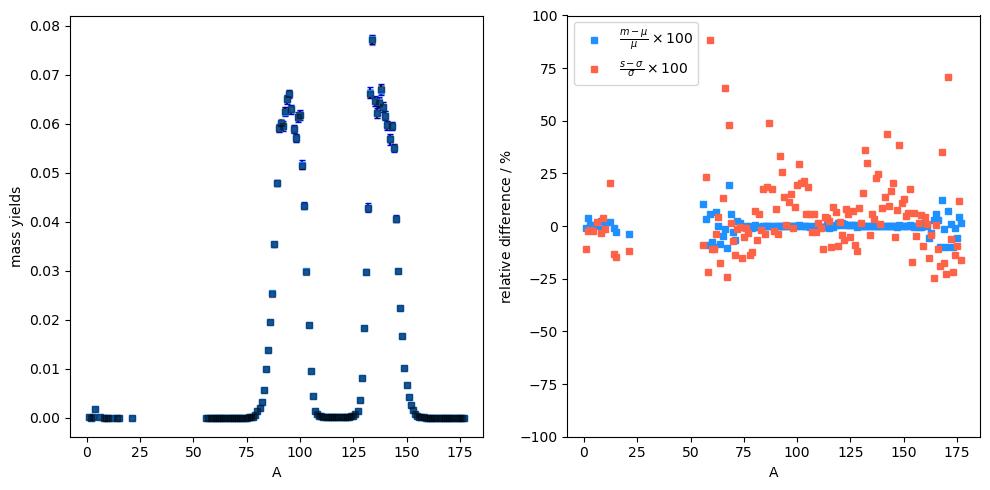

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

ax = axs[0]
ax.errorbar(x=mfy.index, y=mfy.T.mean(), yerr=mfy.T.std(), marker="s", ms=4, linestyle="none", capsize=2, ecolor="blue", color="dodgerblue", label="sample estimate")
ax.errorbar(x=mu.index, y=mu.values, yerr=sigma.values, marker="s", ms=4, linestyle="none", capsize=2, ecolor="k", color="k", alpha=.4, label="original data")
ax.set(ylabel="mass yields", xlabel="A")

ax = axs[1]
diff_mean = (mfy.T.mean() / mu  - 1) * 100
diff_std = (mfy.T.std() / sigma - 1) * 100
ax.errorbar(x=diff_mean.index, y=diff_mean.values, marker="s", ms=4, linestyle="none", color="dodgerblue", label="$\\frac{m- \\mu}{\\mu} \\times 100$")
ax.errorbar(x=diff_std.index, y=diff_std.values, marker="s", ms=4, linestyle="none", color="tomato", label="$\\frac{s- \\sigma}{\\sigma} \\times 100$")
ax.set(ylim=[-100, 100], ylabel="relative difference / $\\%$", xlabel="A")
ax.legend()
fig.tight_layout()